# LAB 04: FEATURE SELECTION


## Thư viện và cấu hình

In [1]:
import os, time, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_regression, f_regression, RFE
from sklearn.linear_model import Ridge, LassoCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor   # pip install xgboost nếu chưa có

# Thư mục chứa train.csv, test.csv  (sửa lại nếu cần)
DATA_DIR = '/mnt/user-data/uploads/' if os.path.exists('/mnt/user-data/uploads/train.csv') else './'
SEEDS = (42, 7, 2024)   # 3 lần chia train/validation để giảm nhiễu

## 1. Tiền xử lý dữ liệu
- Loại 5 outlier `GrLivArea > 4000` 
- Xóa `Id` và các cột thiếu > 70%: `Alley`, `PoolQC`, `Fence`, `MiscFeature`
- Điền khuyết: biến phân loại bằng Mode, biến số bằng Mean
- One-Hot Encoding `drop_first=True`, StandardScaler cho biến số
- Biến mục tiêu: `log1p(SalePrice)` 

In [2]:
train_raw = pd.read_csv(DATA_DIR + 'train.csv'); test_raw = pd.read_csv(DATA_DIR + 'test.csv')
print('Kích thước ban đầu  train:', train_raw.shape, ' test:', test_raw.shape)

# Tỉ lệ thiếu của các cột sẽ bị xóa
drop_cols = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
print((train_raw[drop_cols[1:]].isnull().mean() * 100).round(1))

# 1) Outlier
train = train_raw[train_raw.GrLivArea <= 4000].reset_index(drop=True)
print('Sau khi loại outlier:', train.shape[0], 'dòng')

# 2) Xóa cột
train = train.drop(columns=drop_cols)
test = test_raw.drop(columns=drop_cols)

# MSSubClass là mã loại nhà -> biến danh mục
for d in (train, test): d['MSSubClass'] = d['MSSubClass'].astype(str)

y_all = np.log1p(train.pop('SalePrice'))
cat = [c for c in train if not pd.api.types.is_numeric_dtype(train[c])]
num = [c for c in train if c not in cat]
print('Biến danh mục:', len(cat), '| Biến số:', len(num))

Kích thước ban đầu  train: (1460, 81)  test: (1459, 80)
Alley          93.8
PoolQC         99.5
Fence          80.8
MiscFeature    96.3
dtype: float64
Sau khi loại outlier: 1456 dòng
Biến danh mục: 40 | Biến số: 35


In [3]:
def prep(seed):
    """Chia 80/20, điền khuyết, One-Hot, chuẩn hóa. Mọi thống kê chỉ tính trên train."""
    Xtr, Xva, ytr, yva = train_test_split(train, y_all, test_size=0.2, random_state=seed)
    ntr, nva = len(Xtr), len(Xva)
    fill = {c: (Xtr[c].mode()[0] if c in cat else Xtr[c].mean()) for c in train}
    Xtr, Xva, Xte = [d.fillna(fill) for d in (Xtr, Xva, test)]
    # One-Hot trên dữ liệu gộp để cùng hệ thống cột
    full = pd.get_dummies(pd.concat([Xtr, Xva, Xte]), columns=cat, drop_first=True).astype(float)
    full = full.loc[:, ~full.columns.duplicated()]
    Atr, Ava = full.iloc[:ntr].copy(), full.iloc[ntr:ntr+nva].copy()
    sc = StandardScaler().fit(Atr[num])
    Atr[num] = sc.transform(Atr[num]); Ava[num] = sc.transform(Ava[num])
    return Atr, Ava, ytr, yva, full.shape

Xtr, Xva, ytr, yva, shp = prep(42)
print('Tổng số đặc trưng sau One-Hot:', shp[1])
print('Train:', Xtr.shape, ' Validation:', Xva.shape)

Tổng số đặc trưng sau One-Hot: 248
Train: (1164, 248)  Validation: (292, 248)


## 2. Các kỹ thuật Feature Selection
| Nhóm | Kịch bản | Mô tả |
|---|---|---|
| – | Baseline | Dùng tất cả đặc trưng |
| Filter | Filter-MI-30 / MI-50 | `SelectKBest` + Mutual Information |
| Filter | Filter-F-50 | `SelectKBest` + ANOVA F-test |
| Wrapper | Wrapper-RFE-50 | RFE, mô hình cơ sở Ridge, loại 5 đặc trưng/vòng |
| Embedded | Embedded-Lasso | `LassoCV`, giữ đặc trưng có hệ số ≠ 0 |
| Embedded | Embedded-RFTop50 | Top 50 `feature_importances_` của Random Forest |

In [4]:
def select(name, Xtr, ytr):
    t = time.time(); cols = list(Xtr.columns)
    if name == 'Baseline':
        sel = cols
    elif name.startswith('Filter-MI'):
        k = int(name.split('-')[-1])
        s = SelectKBest(lambda X, y: mutual_info_regression(X, y, random_state=0), k=k).fit(Xtr, ytr); sel = list(Xtr.columns[s.get_support()])
    elif name == 'Filter-F-50':
        s = SelectKBest(f_regression, k=50).fit(Xtr, ytr); sel = list(Xtr.columns[s.get_support()])
    elif name == 'Wrapper-RFE-50':
        s = RFE(Ridge(alpha=1.0), n_features_to_select=50, step=5).fit(Xtr, ytr); sel = list(Xtr.columns[s.support_])
    elif name == 'Embedded-Lasso':
        l = LassoCV(cv=5, random_state=0, max_iter=20000).fit(Xtr, ytr); sel = list(Xtr.columns[l.coef_ != 0])
    elif name == 'Embedded-RFTop50':
        rf = RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1).fit(Xtr, ytr)
        sel = list(pd.Series(rf.feature_importances_, cols).nlargest(50).index)
    return sel, time.time() - t

SCENARIOS = ['Baseline', 'Filter-MI-30', 'Filter-MI-50', 'Filter-F-50',
             'Wrapper-RFE-50', 'Embedded-Lasso', 'Embedded-RFTop50']

def models():   # siêu tham số cố định cho mọi kịch bản để so sánh công bằng
    return {'SVR': SVR(kernel='rbf', C=3, epsilon=0.05, gamma='scale'),
            'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
            'XGBoost': XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=3, min_child_weight=4,
                                    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)}

### 2.1 Ma trận tương quan (Filter – tương quan với SalePrice)
Xem nhanh các đặc trưng số tương quan mạnh nhất với giá nhà.

OverallQual     0.820
GrLivArea       0.731
GarageCars      0.686
GarageArea      0.656
TotalBsmtSF     0.643
1stFlrSF        0.607
YearBuilt       0.595
FullBath        0.583
YearRemodAdd    0.560
TotRmsAbvGrd    0.540
GarageYrBlt     0.500
Fireplaces      0.494
MasVnrArea      0.441
BsmtFinSF1      0.391
LotFrontage     0.337
Name: logSalePrice, dtype: float64


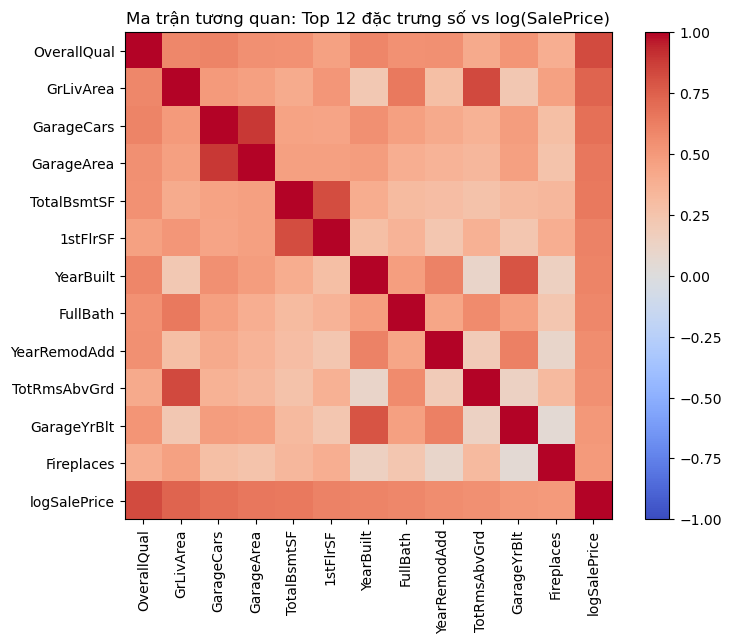

In [5]:
corr_df = Xtr[num].copy(); corr_df['logSalePrice'] = ytr.values
corr = corr_df.corr()['logSalePrice'].drop('logSalePrice').sort_values(key=abs, ascending=False)
print(corr.head(15).round(3))

top = list(corr.head(12).index) + ['logSalePrice']
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr_df[top].corr(), cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(top))); ax.set_xticklabels(top, rotation=90)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top)
plt.colorbar(im); ax.set_title('Ma trận tương quan: Top 12 đặc trưng số vs log(SalePrice)')
plt.tight_layout(); plt.show()

## 3. Huấn luyện & đánh giá
7 kịch bản × 3 mô hình × 3 lần chia = 63 lần huấn luyện. Metrics: RMSLE (thang log), RMSE/MAE/R² (quy về đô la), thời gian huấn luyện.

In [6]:
rows, sels = [], {}
for seed in SEEDS:
    Xtr, Xva, ytr, yva, shp = prep(seed)
    for s in SCENARIOS:
        sel, tsel = select(s, Xtr, ytr)
        if seed == 42: sels[s] = sel
        for m, mod in models().items():
            t = time.time(); mod.fit(Xtr[sel], ytr); tt = time.time() - t
            p = mod.predict(Xva[sel]); a, b = np.expm1(yva), np.expm1(p)
            rows.append(dict(seed=seed, scenario=s, model=m, n_feat=len(sel),
                             RMSLE=np.sqrt(mean_squared_error(yva, p)),
                             RMSE=np.sqrt(mean_squared_error(a, b)), MAE=mean_absolute_error(a, b),
                             R2=r2_score(a, b), train_time=tt, sel_time=tsel))
    print('Xong seed', seed, flush=True)
df = pd.DataFrame(rows)
df.to_csv('lab04_ketqua_chitiet.csv', index=False)

Xong seed 42
Xong seed 7
Xong seed 2024


## 4. Tổng hợp kết quả (trung bình 3 lần chia)

In [7]:
g = df.groupby(['model', 'scenario'], sort=False).agg(
    n_feat=('n_feat', 'mean'), RMSLE=('RMSLE', 'mean'), RMSLE_sd=('RMSLE', 'std'),
    RMSE=('RMSE', 'mean'), MAE=('MAE', 'mean'), R2=('R2', 'mean'),
    train_time=('train_time', 'mean'), sel_time=('sel_time', 'mean')).reset_index()
g['n_feat'] = g.n_feat.round()
pd.set_option('display.width', 200)
g.to_csv('lab04_tonghop.csv', index=False)          # bảng tổng hợp dùng cho báo cáo
for m in ['SVR', 'RandomForest', 'XGBoost']:
    print('\n=====', m, '=====')
    display(g[g.model == m].drop(columns='model').set_index('scenario').round(4))


===== SVR =====


,n_feat,RMSLE,RMSLE_sd,RMSE,MAE,R2,train_time,sel_time
scenario,,,,,,,,
Baseline,248.0,0.1414,0.0096,27837.1624,16835.5125,0.8654,0.1808,0.0001
Filter-MI-30,30.0,0.1462,0.0042,28617.7494,18026.4354,0.8585,0.1386,2.5469
Filter-MI-50,50.0,0.1455,0.0023,29021.1294,18164.7147,0.8547,0.1628,2.3600
Filter-F-50,50.0,0.1520,0.0062,29030.4430,18980.8760,0.8546,0.2100,0.0146
Wrapper-RFE-50,50.0,0.1446,0.0107,28362.8318,18126.0687,0.8611,0.2295,0.2902
Embedded-Lasso,101.0,0.1454,0.0097,29160.1693,17460.2367,0.8523,0.1658,0.5566
Embedded-RFTop50,50.0,0.1414,0.0032,28087.2564,17266.1370,0.8637,0.1652,3.7698



===== RandomForest =====


,n_feat,RMSLE,RMSLE_sd,RMSE,MAE,R2,train_time,sel_time
scenario,,,,,,,,
Baseline,248.0,0.1414,0.0150,26654.7328,17658.3563,0.8771,3.6740,0.0001
Filter-MI-30,30.0,0.1455,0.0148,27185.0511,17973.0367,0.8718,1.7569,2.5469
Filter-MI-50,50.0,0.1426,0.0137,26949.1608,17746.7264,0.8745,2.0284,2.3600
Filter-F-50,50.0,0.1479,0.0140,27544.0103,18281.0189,0.8687,1.9646,0.0146
Wrapper-RFE-50,50.0,0.1526,0.0123,28516.4355,18725.4753,0.8596,1.0430,0.2902
Embedded-Lasso,101.0,0.1410,0.0143,26562.9070,17588.5160,0.8780,2.5277,0.5566
Embedded-RFTop50,50.0,0.1416,0.0144,26709.1501,17674.4902,0.8766,2.1502,3.7698



===== XGBoost =====


,n_feat,RMSLE,RMSLE_sd,RMSE,MAE,R2,train_time,sel_time
scenario,,,,,,,,
Baseline,248.0,0.1217,0.0070,22169.9786,14459.8564,0.9151,3.1321,0.0001
Filter-MI-30,30.0,0.1325,0.0104,24493.5584,16246.4976,0.8961,1.5848,2.5469
Filter-MI-50,50.0,0.1287,0.0078,23944.9649,15778.7284,0.9009,1.8237,2.3600
Filter-F-50,50.0,0.1370,0.0086,25203.4339,16951.1086,0.8904,1.8998,0.0146
Wrapper-RFE-50,50.0,0.1436,0.0100,27272.3420,17497.9981,0.8711,1.4770,0.2902
Embedded-Lasso,101.0,0.1222,0.0087,22147.9097,14812.3898,0.9150,2.3469,0.5566
Embedded-RFTop50,50.0,0.1257,0.0091,23792.4165,15719.0179,0.9021,1.9071,3.7698


### Biểu đồ so sánh

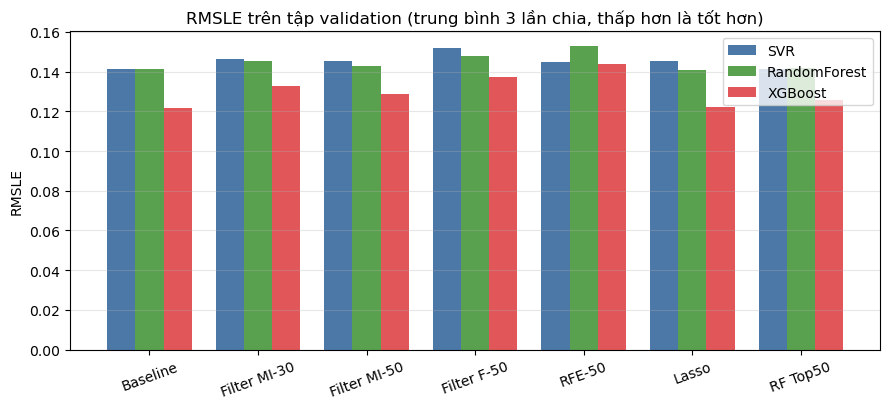

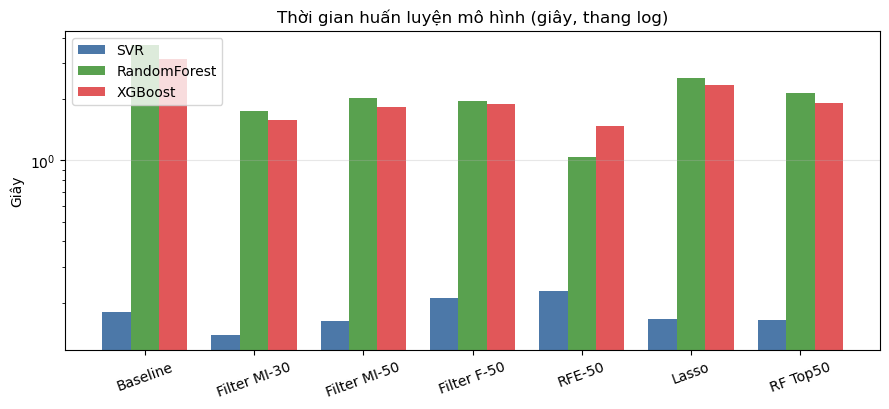

In [8]:
lab = ['Baseline', 'Filter MI-30', 'Filter MI-50', 'Filter F-50', 'RFE-50', 'Lasso', 'RF Top50']
col = ['#4C78A8', '#59A14F', '#E15759']
def bar(metric, title, ylabel, fname, log=False):
    fig, ax = plt.subplots(figsize=(9, 4.2)); w = 0.26
    for i, m in enumerate(['SVR', 'RandomForest', 'XGBoost']):
        v = [g[(g.model == m) & (g.scenario == s)][metric].iloc[0] for s in SCENARIOS]
        ax.bar(np.arange(len(SCENARIOS)) + (i - 1) * w, v, w, label=m, color=col[i])
    ax.set_xticks(range(len(SCENARIOS))); ax.set_xticklabels(lab, rotation=20)
    ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(axis='y', alpha=.3); ax.legend()
    if log: ax.set_yscale('log')
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()
bar('RMSLE', 'RMSLE trên tập validation (trung bình 3 lần chia, thấp hơn là tốt hơn)', 'RMSLE', 'hinh1_rmsle.png')
bar('train_time', 'Thời gian huấn luyện mô hình (giây, thang log)', 'Giây', 'hinh2_thoigian.png', log=True)

In [9]:
# Mức giảm thời gian huấn luyện so với Baseline
t = g.pivot(index='scenario', columns='model', values='train_time').loc[SCENARIOS]
print((100 * (1 - t / t.loc['Baseline'])).round(0).astype(int).astype(str) + '%')

# Chi phí của chính bước chọn đặc trưng
print(g[g.model == 'SVR'].set_index('scenario')[['n_feat', 'sel_time']].round(3))

# Đặc trưng được nhiều phương pháp chọn nhất (seed 42)
ks = [k for k in sels if k != 'Baseline']
print('Chọn bởi cả 6 phương pháp:', sorted(set.intersection(*[set(sels[k]) for k in ks])))
print(pd.Series([f for k in ks for f in sels[k]]).value_counts().head(15))
json.dump(sels, open('lab04_dactrung_chon.json', 'w'))   # danh sách đặc trưng được chọn (seed 42)
json.dump({'n_features': int(shp[1]), 'n_train': len(Xtr), 'n_valid': len(Xva)}, open('lab04_info.json', 'w'))

model            RandomForest   SVR XGBoost
scenario                                   
Baseline                   0%    0%      0%
Filter-MI-30              52%   23%     49%
Filter-MI-50              45%   10%     42%
Filter-F-50               47%  -16%     39%
Wrapper-RFE-50            72%  -27%     53%
Embedded-Lasso            31%    8%     25%
Embedded-RFTop50          41%    9%     39%
                  n_feat  sel_time
scenario                          
Baseline           248.0     0.000
Filter-MI-30        30.0     2.547
Filter-MI-50        50.0     2.360
Filter-F-50         50.0     0.015
Wrapper-RFE-50      50.0     0.290
Embedded-Lasso     101.0     0.557
Embedded-RFTop50    50.0     3.770
Chọn bởi cả 6 phương pháp: ['BsmtQual_Gd', 'GarageCars', 'GrLivArea', 'KitchenQual_Gd', 'KitchenQual_TA', 'OverallQual', 'YearBuilt']
OverallQual          6
YearBuilt            6
KitchenQual_TA       6
KitchenQual_Gd       6
BsmtQual_Gd          6
GrLivArea            6
GarageCars       

In [10]:
# Lưu kết quả tổng hợp, danh sách đặc trưng và số liệu tiền xử lý (dùng để lập báo cáo)
g.to_csv('lab04_tonghop.csv', index=False)
json.dump(sels, open('lab04_dactrung_duocchon.json', 'w'), ensure_ascii=False, indent=1)
print('Đã lưu: lab04_ketqua_chitiet.csv, lab04_tonghop.csv, lab04_dactrung_duocchon.json, hinh1_rmsle.png, hinh2_thoigian.png')

Đã lưu: lab04_ketqua_chitiet.csv, lab04_tonghop.csv, lab04_dactrung_duocchon.json, hinh1_rmsle.png, hinh2_thoigian.png


In [11]:
# --- Phân tích bổ sung (số liệu dùng cho phần nhận xét) ---
# (a) Chênh lệch RMSLE so với Baseline (dương = tệ hơn Baseline)
rm = g.pivot(index='scenario', columns='model', values='RMSLE').loc[SCENARIOS]
delta = (rm - rm.loc['Baseline']).round(4); delta['Trung bình'] = delta.mean(axis=1).round(4)
print('Chênh lệch RMSLE so với Baseline:'); display(delta)

# (b) Tổng thời gian = chọn đặc trưng + huấn luyện (1 lần), so với Baseline
tt = g.pivot(index='scenario', columns='model', values='train_time').loc[SCENARIOS]
selt = g.groupby('scenario').sel_time.first().loc[SCENARIOS]
total = tt.add(selt, axis=0).round(3)
print('Tổng thời gian (chọn ĐT + huấn luyện, giây):'); display(total)

# (c) Thành phần đặc trưng được chọn: biến số hay one-hot
numset = set(num)
comp = pd.DataFrame({s: {'Số đặc trưng': len(v), 'Biến số': sum(f in numset for f in v),
                         'One-hot': sum(f not in numset for f in v)} for s, v in sels.items()}).T
print('Thành phần đặc trưng (seed 42):'); display(comp)

# (d) Độ trùng lặp giữa các phương pháp (seed 42)
ks = [k for k in sels if k != 'Baseline']
ov = pd.DataFrame([[len(set(sels[a]) & set(sels[b])) for b in ks] for a in ks], index=ks, columns=ks)
print('Số đặc trưng trùng nhau giữa các phương pháp:'); display(ov)

delta.to_csv('lab04_delta_rmsle.csv'); total.to_csv('lab04_tongthoigian.csv'); comp.to_csv('lab04_thanhphan.csv'); ov.to_csv('lab04_trunglap.csv')

Chênh lệch RMSLE so với Baseline:


model,RandomForest,SVR,XGBoost,Trung bình
scenario,,,,
Baseline,0.0000,0.0000,0.0000,0.0000
Filter-MI-30,0.0041,0.0049,0.0108,0.0066
Filter-MI-50,0.0011,0.0041,0.0070,0.0041
Filter-F-50,0.0065,0.0106,0.0153,0.0108
Wrapper-RFE-50,0.0112,0.0032,0.0219,0.0121
Embedded-Lasso,-0.0004,0.0040,0.0005,0.0014
Embedded-RFTop50,0.0002,0.0000,0.0040,0.0014


Tổng thời gian (chọn ĐT + huấn luyện, giây):


model,RandomForest,SVR,XGBoost
scenario,,,
Baseline,3.674,0.181,3.132
Filter-MI-30,4.304,2.685,4.132
Filter-MI-50,4.388,2.523,4.184
Filter-F-50,1.979,0.225,1.914
Wrapper-RFE-50,1.333,0.520,1.767
Embedded-Lasso,3.084,0.722,2.903
Embedded-RFTop50,5.920,3.935,5.677


Thành phần đặc trưng (seed 42):


,Số đặc trưng,Biến số,One-hot
Baseline,248,35,213
Filter-MI-30,30,19,11
Filter-MI-50,50,23,27
Filter-F-50,50,19,31
Wrapper-RFE-50,50,4,46
Embedded-Lasso,85,33,52
Embedded-RFTop50,50,28,22


Số đặc trưng trùng nhau giữa các phương pháp:


,Filter-MI-30,Filter-MI-50,Filter-F-50,Wrapper-RFE-50,Embedded-Lasso,Embedded-RFTop50
Filter-MI-30,30,30,27,8,26,26
Filter-MI-50,30,50,43,12,37,35
Filter-F-50,27,43,50,13,36,33
Wrapper-RFE-50,8,12,13,50,27,14
Embedded-Lasso,26,37,36,27,85,40
Embedded-RFTop50,26,35,33,14,40,50
